In [2]:
!pip install msprime tskit scikit-learn kmapper ripser matplotlib networkx plotly igraph ipywidgets persim -q

In [3]:
import msprime
import tskit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
import kmapper as km
from kmapper.adapter import to_networkx
from ripser import Rips
from persim import plot_diagrams
import warnings
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from persim import plot_diagrams
warnings.filterwarnings("ignore")

In [3]:
import os
dir='mapper_outputs'
os.makedirs(dir,exist_ok=True)

In [4]:
print('1. Filter functions')
filter_functions = pd.read_csv('filter_functions.csv')
display(filter_functions)

1. Filter functions


,filter_id,filter_name,filter_dim
0,1,MDS1,1
1,2,distance_to_medoid,1
2,3,mean_distance,1
3,4,introgressed_fraction,1
4,5,tract_count,1
5,6,mean_tract_length,1


In [5]:
print('2. Individual biology')
individual_biology = pd.read_csv('individual_biology.csv')
display(individual_biology)

2. Individual biology


,scenario,individual_id,introgressed_windows,introgressed_fraction,tract_count,mean_tract_length
0,one_pulse,0,5067,0.168900,62,80699.709677
1,one_pulse,1,5850,0.195000,65,89044.892308
2,one_pulse,2,5432,0.181067,57,94364.614035
3,one_pulse,3,4766,0.158867,69,68108.840580
4,one_pulse,4,5566,0.185533,71,77391.211268
...,...,...,...,...,...,...
295,one_pulse_desert,95,3982,0.132733,57,68869.105263
296,one_pulse_desert,96,4713,0.157100,58,80337.793103
297,one_pulse_desert,97,4501,0.150033,59,75286.000000
298,one_pulse_desert,98,4448,0.148267,52,84527.076923


In [6]:
print('3. Mapper summary')
mapper_summary_df = pd.read_csv('mapper_summary.csv')
print(mapper_summary_df.to_string(index=False))

3. Mapper summary
        scenario  filter_id      eps  cover_intervals  cover_overlap  nodes  edges  components  diameter  branch_nodes  cycles
       one_pulse          1 0.641467                8            0.3      8      7           1         7             0       0
       one_pulse          2 0.641467                8            0.3      3      2           1         2             0       0
       one_pulse          3 0.641467                8            0.3      8      6           2         6             0       0
       one_pulse          4 0.641467                8            0.3      6      5           1         5             0       0
       one_pulse          5 0.641467                8            0.3      7      6           1         6             0       0
       one_pulse          6 0.641467                8            0.3      8      7           1         7             0       0
      two_pulses          1 0.641467                8            0.3      5      1           

In [7]:
print('4. Mapper node biology') 
mapper_node_biology = pd.read_csv('mapper_node_biology.csv')
print(mapper_node_biology.head(25).to_string(index=False)) 

4. Mapper node biology
 scenario  filter_id        node_id  node_size  mean_introgressed_windows  mean_introgressed_fraction  mean_tract_count  mean_tract_length
one_pulse          1 cube0_cluster0         14                5211.500000                    0.173717         66.000000       78140.502153
one_pulse          1 cube1_cluster0         18                5462.388889                    0.182080         67.333333       80541.642101
one_pulse          1 cube2_cluster0         18                5107.444444                    0.170248         64.555556       78542.907594
one_pulse          1 cube3_cluster0         19                5426.894737                    0.180896         65.736842       82163.522148
one_pulse          1 cube4_cluster0         18                5349.388889                    0.178313         65.944444       80407.417802
one_pulse          1 cube5_cluster0         19                5437.736842                    0.181258         63.789474       84584.968572
one_

In [8]:
print('5. Ph summary') 
ph_summary = pd.read_csv('ph_summary.csv')
print(ph_summary.to_string(index=False)) 

5. Ph summary
 H0_total_persistence  H0_max_persistence  H1_total_persistence  H1_max_persistence  H1_number_of_features         scenario
            50.536658            0.591494              1.549051            0.040536                    124        one_pulse
            64.648669            0.732565              3.358281            0.063725                    174       two_pulses
            49.638211            0.559117              1.599830            0.055619                    132 one_pulse_desert


In [9]:
print('6. Analysis parameters')
analysis_parameters = pd.read_csv('analysis_parameters.csv')
print(analysis_parameters.to_string(index=False)) 

6. Analysis parameters
                                run_id         scenario feature_type  metric  window_size  filter_id      eps  cover_intervals  cover_overlap mds_mode
                        one_pulse_MDS1        one_pulse       binary jaccard         1000          1 0.641467                8            0.3       1D
          one_pulse_distance_to_medoid        one_pulse       binary jaccard         1000          2 0.641467                8            0.3       1D
               one_pulse_mean_distance        one_pulse       binary jaccard         1000          3 0.641467                8            0.3       1D
       one_pulse_introgressed_fraction        one_pulse       binary jaccard         1000          4 0.641467                8            0.3       1D
                 one_pulse_tract_count        one_pulse       binary jaccard         1000          5 0.641467                8            0.3       1D
           one_pulse_mean_tract_length        one_pulse       binary ja

In [10]:
print('3. Scenario summary')
scenario_summary_df = pd.read_csv('scenario_summary.csv')
print(scenario_summary_df.to_string(index=False))

3. Scenario summary
        scenario  mean_introgressed_fraction  mean_introgressed_windows  mean_tract_count  mean_tract_length
       one_pulse                    0.175228                    5256.83             65.18       80041.918234
one_pulse_desert                    0.147781                    4433.43             54.36       81083.091846
      two_pulses                    0.078878                    2366.35             31.43       74592.747688


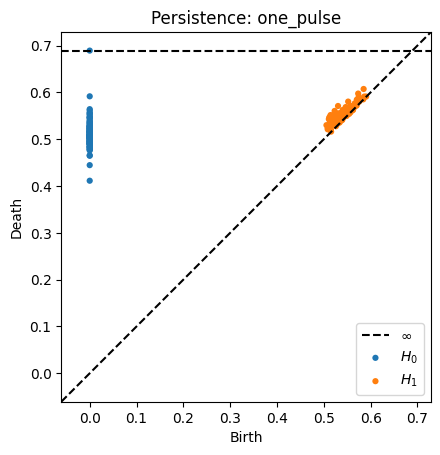

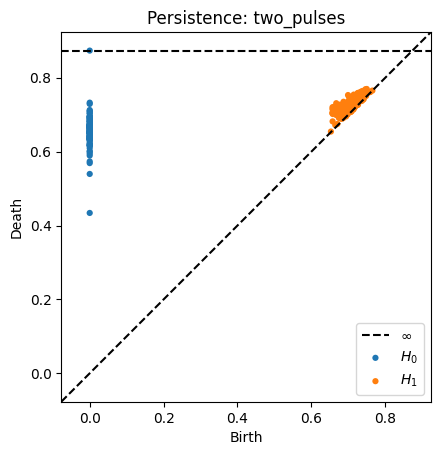

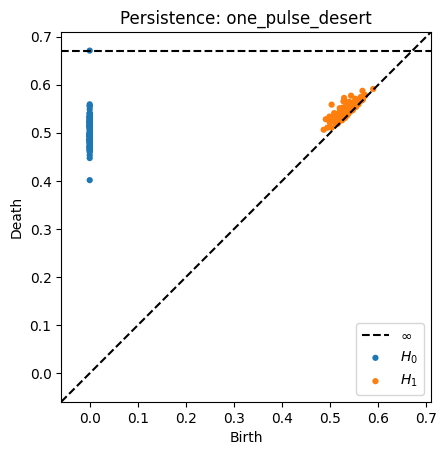

In [11]:
persistence_results = joblib.load('persistence/persistence_results.joblib')

for scenario in persistence_results.keys():
    diagrams = persistence_results[scenario]['diagrams']
    plt.figure()
    plot_diagrams(diagrams)
    plt.title(f"Persistence: {scenario}")
    plt.show()


file:///Users/siriliza/Desktop/neanderthals/results/mapper/mapper_one_pulse.html

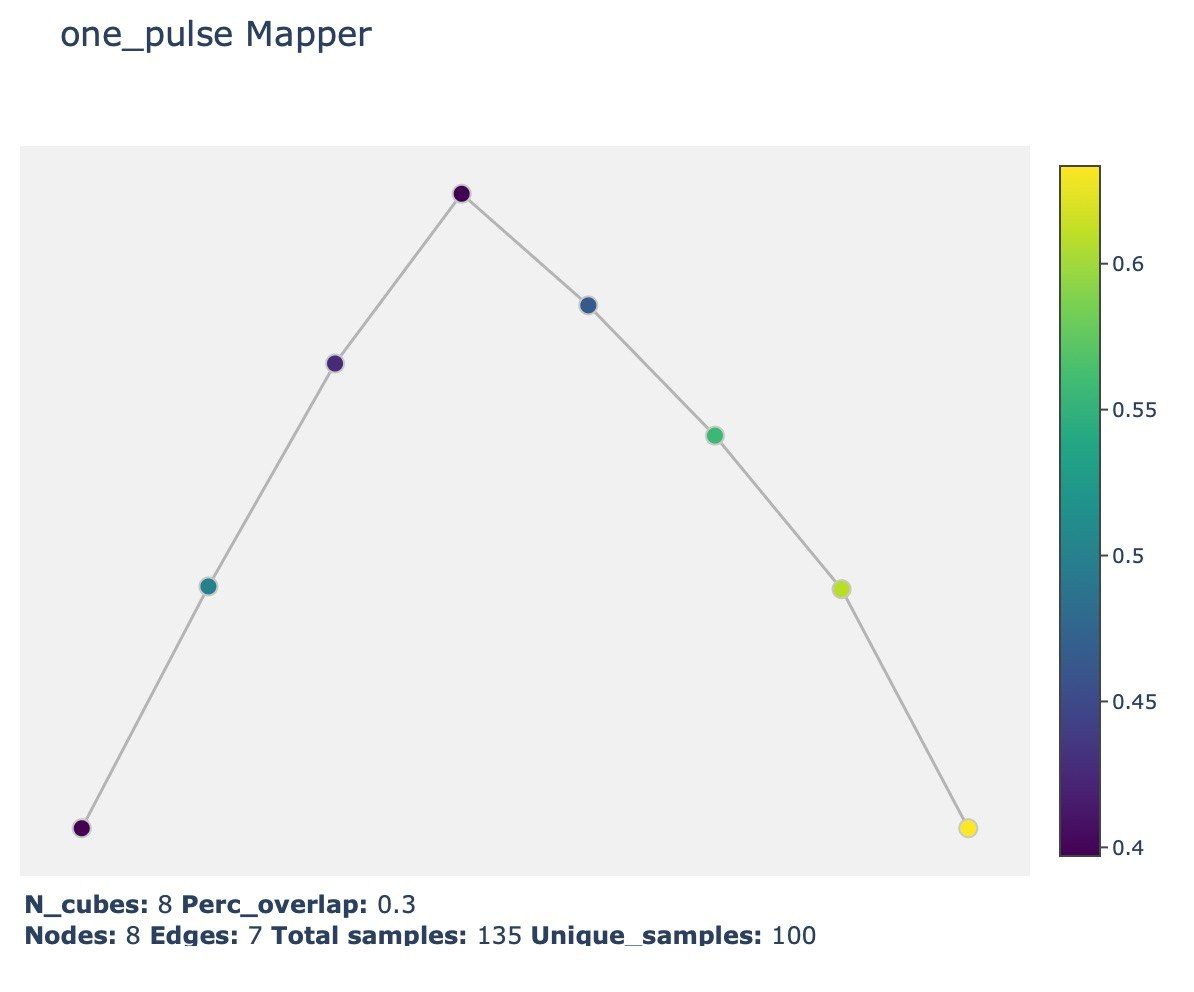

In [5]:
from IPython.display import Image, display

display(Image('mapper/one_pulse_mapper.jpeg'))

file:///Users/siriliza/Desktop/neanderthals/results/mapper/mapper_two_pulses.html

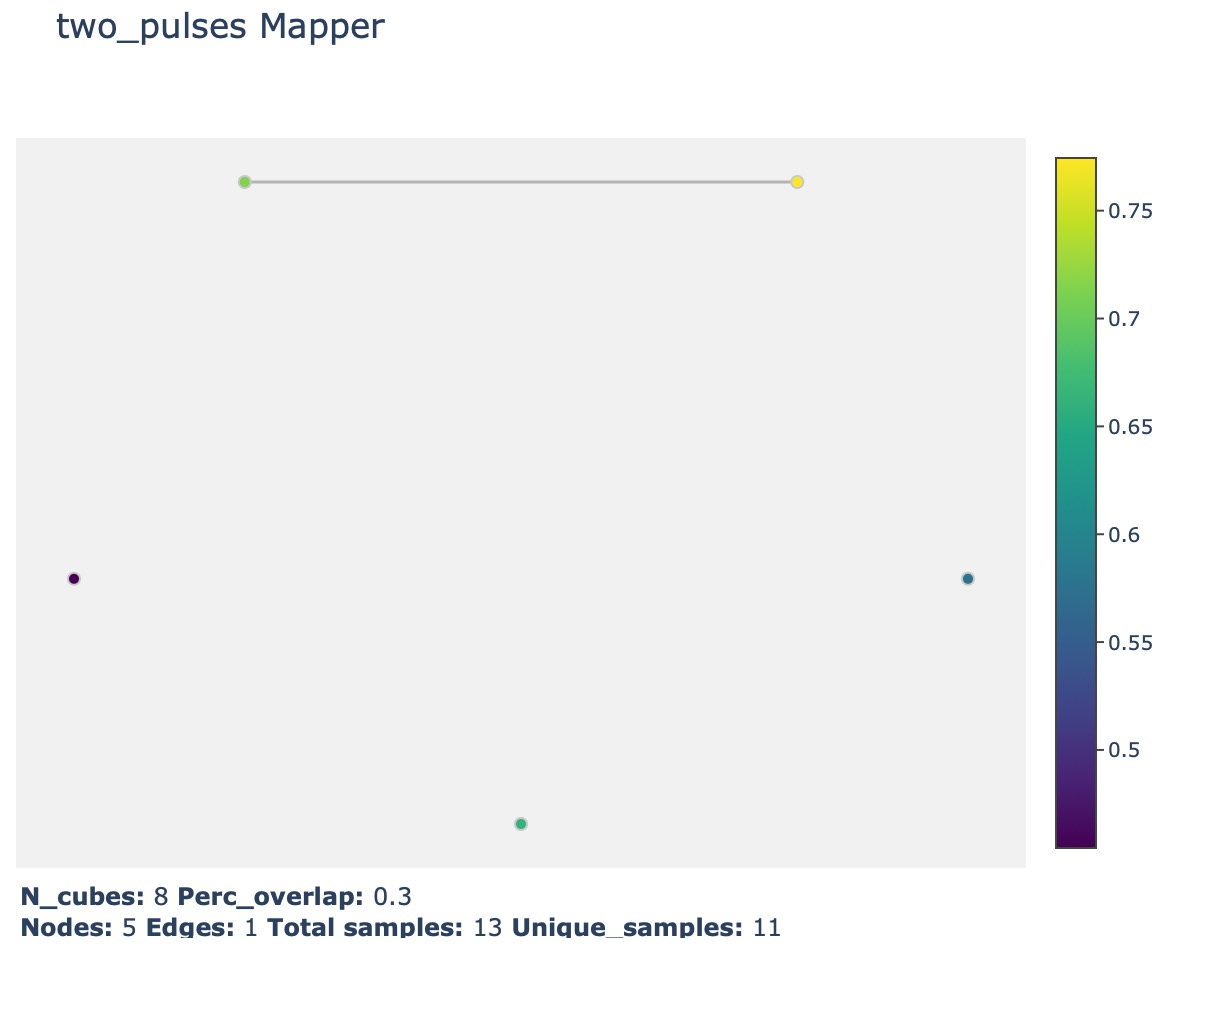

In [6]:
display(Image('mapper/two_pulses_mapper.jpeg'))

file:///Users/siriliza/Desktop/neanderthals/results/mapper/mapper_one_pulse_desert.html

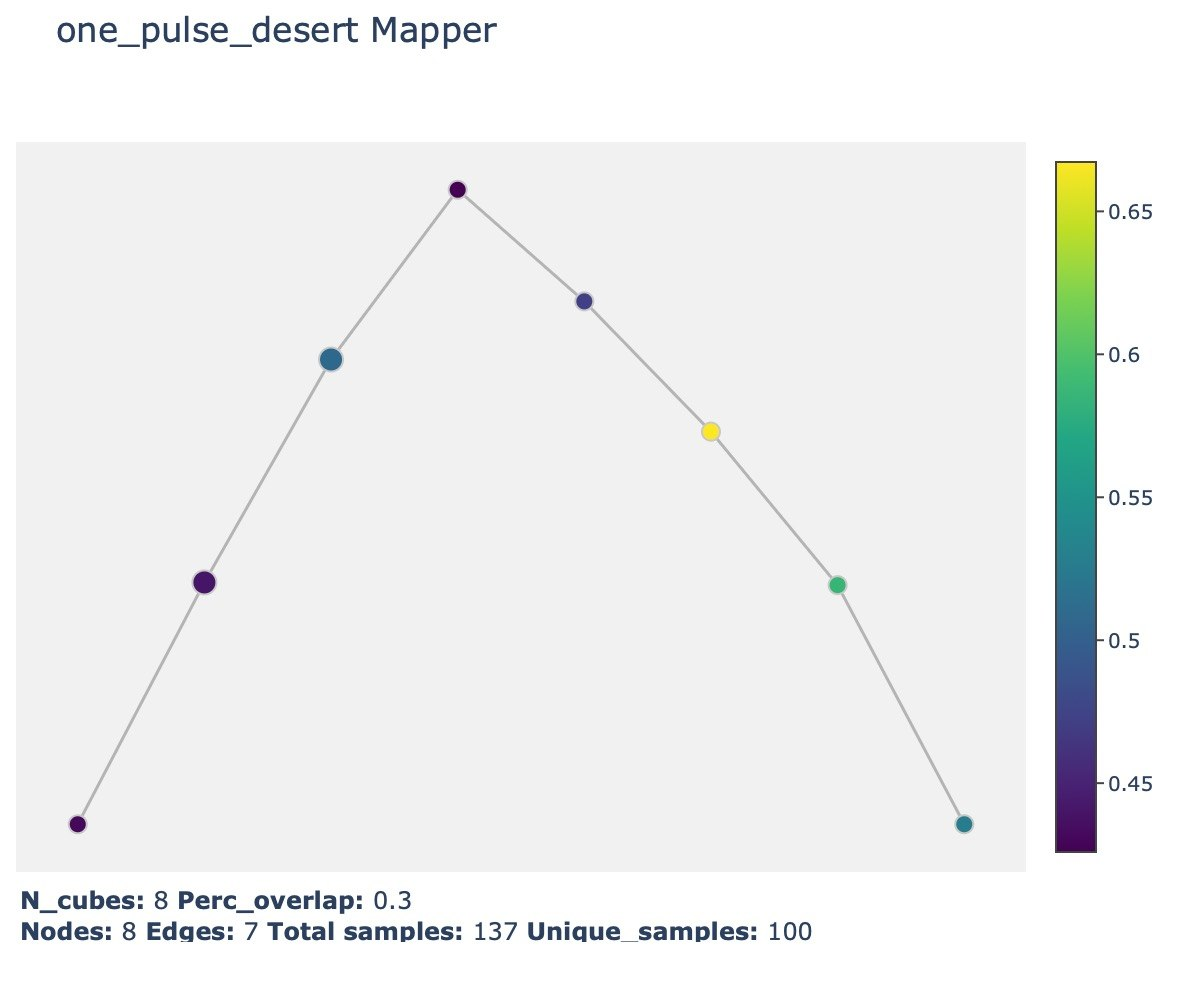

In [17]:
display(Image('mapper/one_pulse_w_desert_mapper.jpeg'))